In [1]:
import os
from pathlib import Path

from lsdb import read_hats

from hats_import_vizier import vizier_to_hats

In [7]:
import dask.distributed
import matplotlib.pyplot as plt
import nested_pandas as npd
import numpy as np
import pandas as pd
import pyarrow as pa

from lsdb import open_catalog, from_dataframe
from nested_pandas.series.dtype import NestedDtype
from upath import UPath

## get gaia variable AGN catalog

In [2]:
VIZIER_PREFIX = "I/358/"
VIZIER_CATALOG_SUFFIXES = ["vagn"]
CATALOG_NAME_PREFIX = "gaia_dr3_"

HATS_PATH = Path("./hats")
TEMP_PATH = Path("./temp")

HATS_PATH.mkdir(exist_ok=True, parents=True)
TEMP_PATH.mkdir(exist_ok=True, parents=True)

In [5]:
for cat_suf in VIZIER_CATALOG_SUFFIXES:
    vizier_catalog = VIZIER_PREFIX + cat_suf
    catalog_name = CATALOG_NAME_PREFIX + cat_suf

    '''
    vizier_to_hats(
        vizier_catalog,
        hats_path=HATS_PATH,
        hats_name=catalog_name,
        tmp_path=TEMP_PATH,
        cache_path=TEMP_PATH,
        vizier_kwargs={"columns": ["**"]},  # all columns
    )
    '''
    print(catalog_name)
    lsdb_catalog = read_hats(
        HATS_PATH / catalog_name,
        margin_cache=HATS_PATH / f"{catalog_name}",
    )
    display(lsdb_catalog)
    print(len(lsdb_catalog), len(lsdb_catalog.margin))

gaia_dr3_vagn


,_RAJ2000,_DEJ2000,recno,Source,SolID,fvarG,SFIndex,s_SFIndex,QSOVar,NonQSOVar,RA_ICRS,DE_ICRS
npartitions=21,,,,,,,,,,,,
"Order: 0, Pixel: 0",double[pyarrow],double[pyarrow],int32[pyarrow],int64[pyarrow],int64[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow]
"Order: 1, Pixel: 4",...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 0, Pixel: 10",...,...,...,...,...,...,...,...,...,...,...,...
"Order: 0, Pixel: 11",...,...,...,...,...,...,...,...,...,...,...,...


872228 872228


In [6]:
lsdb_catalog.head(5)

,_RAJ2000,_DEJ2000,recno,Source,SolID,fvarG,SFIndex,s_SFIndex,QSOVar,NonQSOVar,RA_ICRS,DE_ICRS
_healpix_29,,,,,,,,,,,,
5459300688871,45.188575,0.282424,19226,10892037246720,375316653866487564,0.043431,1.151587,0.320949,-0.59914,0.930711,45.188575,0.282424
7934686219821,45.18948,0.359195,127980,15839839588736,375316653866487564,0.117908,0.748897,0.197819,0.362599,0.617132,45.18948,0.359195
9638946424419,44.835496,0.237432,180466,19275813399552,375316653866487564,0.098453,0.505764,0.298302,-0.320331,0.392287,44.835496,0.237432
11393243897831,44.799365,0.303557,202734,22780506725760,375316653866487564,0.026437,0.413799,0.360165,-0.555482,0.409713,44.799365,0.303557
17571969660372,44.991067,0.581729,368186,35115652874752,375316653866487564,0.052366,0.681788,0.44182,-0.473468,0.513366,44.991067,0.581729


## get gaia epoch photometry catalog

In [8]:
GAIA_EPOCH_PHOT_PATH = "https://data.lsdb.io/hats/gaia_dr3_epoch_phot/"

In [9]:
# Load Gaia DR3 epoch photometry metadata
gaia_epoch_phot = open_catalog(
    GAIA_EPOCH_PHOT_PATH,
    columns=[
        "source_id",
        "ra",
        "dec",
        # G-band epoch photometry
        "epoch_photometry.g_transit_time",
        "epoch_photometry.g_transit_mag",
        "epoch_photometry.g_transit_flux_over_error",
        "epoch_photometry.variability_flag_g_reject",
        # BP-band epoch photometry
        "epoch_photometry.bp_obs_time",
        "epoch_photometry.bp_mag",
        "epoch_photometry.bp_flux_over_error",
        "epoch_photometry.variability_flag_bp_reject",
        # RP-band epoch photometry
        "epoch_photometry.rp_obs_time",
        "epoch_photometry.rp_mag",
        "epoch_photometry.rp_flux_over_error",
        "epoch_photometry.variability_flag_rp_reject",
    ],
)
display(gaia_epoch_phot)

,source_id,ra,dec,epoch_photometry
npartitions=1305,,,,
"Order: 2, Pixel: 0",int64[pyarrow],double[pyarrow],double[pyarrow],"nested<g_transit_time: [double], g_transit_mag..."
"Order: 2, Pixel: 1",...,...,...,...
...,...,...,...,...
"Order: 3, Pixel: 766",...,...,...,...
"Order: 3, Pixel: 767",...,...,...,...


In [10]:
gaia_epoch_phot.head()

source_id         ra       dec  \
_healpix_29                                          
5337174887882  10655814178816  45.176533   0.26083   
5459300688871  10892037246720  45.188575  0.282424   
7130979436382  14263587225600  45.134758  0.321555   
7934686219821  15839839588736   45.18948  0.359195   
9638946424419  19275813399552  44.835496  0.237432   

                                                epoch_photometry  
_healpix_29                                                       
5337174887882  [{g_transit_time: 1820.858245, g_transit_mag: ...  
5459300688871  [{g_transit_time: 1709.445651, g_transit_mag: ...  
7130979436382  [{g_transit_time: 1709.445621, g_transit_mag: ...  
7934686219821  [{g_transit_time: 1709.445602, g_transit_mag: ...  
9638946424419  [{g_transit_time: 1709.371812, g_transit_mag: ...

## convert GAIA LC & match by RA Dec

In [11]:
# Gaia DR3 epoch photometry reference epoch: BJD 2455197.5 (TCB) = 2010-01-01
# Times in the catalog are BJD - 2455197.5, so MJD = time + 2455197.5 - 2400000.5
GAIA_TIME_OFFSET_TO_MJD = 55197.0

# Approximate Vega-to-AB magnitude offsets for Gaia DR3 passbands
# See https://www.cosmos.esa.int/web/gaia/dr3-passbands
GAIA_VEGA_TO_AB = {"G": 0.126, "BP": 0.024, "RP": 0.383}


def parse_gaia_epoch_photometry(
    g_time,
    g_mag,
    g_s2n,
    g_flag,
    bp_time,
    bp_mag,
    bp_s2n,
    bp_flag,
    rp_time,
    rp_mag,
    rp_s2n,
    rp_flag,
    *,
    min_s2n=3.0,
):
    """Transform Gaia DR3 epoch photometry from wide per-band arrays to a
    standard long-format light curve with quality filtering.

    Filters observations by flux_over_error > min_s2n,
    converts times to MJD, and converts magnitudes from Vega to AB system.
    """
    mjds, mags, mag_errs, bands = [], [], [], []
    for band, time_arr, mag_arr, s2n_arr, flag_arr in [
            ("G", g_time, g_mag, g_s2n, g_flag),
            ("BP", bp_time, bp_mag, bp_s2n, bp_flag),
            ("RP", rp_time, rp_mag, rp_s2n, rp_flag),
        ]:
    
        #print(g_flag, bp_flag, rp_flag)
        
        time_arr = np.asarray(time_arr, dtype=np.float64)
        mag_arr = np.asarray(mag_arr, dtype=np.float64)
        s2n_arr = np.asarray(s2n_arr, dtype=np.float64)
        flag_arr = np.asarray(g_flag) | np.asarray(bp_flag) | np.asarray(rp_flag)
    
        # Quality filter: keep only observations with sufficient signal-to-noise
        good = (s2n_arr > min_s2n) & ~flag_arr
        t = time_arr[good] + GAIA_TIME_OFFSET_TO_MJD
        m = mag_arr[good] + GAIA_VEGA_TO_AB[band]
        # mag_err ≈ 1.0857 / flux_over_error (from error propagation of -2.5*log10(flux))
        m_err = 2.5 / np.log(10.0) / s2n_arr[good]
    
        mjds.append(t)
        mags.append(m)
        mag_errs.append(m_err)
        bands.extend([band] * len(t))

    return {
        "gaia_lc.mjd": np.concatenate(mjds) if mjds else np.array([], dtype=np.float64),
        "gaia_lc.mag": np.concatenate(mags) if mags else np.array([], dtype=np.float64),
        "gaia_lc.mag_err": np.concatenate(mag_errs) if mag_errs else np.array([], dtype=np.float64),
        "gaia_lc.band": bands,
    }

In [12]:
gaia_lc = lsdb_catalog.crossmatch(
    gaia_epoch_phot,
    radius_arcsec=1.0,
    suffixes=["", ""],
    suffix_method="overlapping_columns",
)

# Define the output metadata for the parsed light curve nested column
gaia_lc_dtype = NestedDtype(
    pa.struct(
        [
            pa.field("mjd", pa.list_(pa.float64())),
            pa.field("mag", pa.list_(pa.float64())),
            pa.field("mag_err", pa.list_(pa.float64())),
            pa.field("band", pa.list_(pa.string())),
        ]
    )
)

In [13]:
gaia_lc.head(5)

_RAJ2000  _DEJ2000   recno          Source  \
_healpix_29                                                   
5459300688871   45.188575  0.282424   19226  10892037246720   
7934686219821    45.18948  0.359195  127980  15839839588736   
9638946424419   44.835496  0.237432  180466  19275813399552   
11393243897831  44.799365  0.303557  202734  22780506725760   
17571969660372  44.991067  0.581729  368186  35115652874752   

                             SolID     fvarG   SFIndex  s_SFIndex    QSOVar  \
_healpix_29                                                                   
5459300688871   375316653866487564  0.043431  1.151587   0.320949  -0.59914   
7934686219821   375316653866487564  0.117908  0.748897   0.197819  0.362599   
9638946424419   375316653866487564  0.098453  0.505764   0.298302 -0.320331   
11393243897831  375316653866487564  0.026437  0.413799   0.360165 -0.555482   
17571969660372  375316653866487564  0.052366  0.681788    0.44182 -0.473468   

                NonQSOVar    RA_ICRS   DE_ICRS       source_id         ra  \
_healpix_29                                                                 
5459300688871    0.930711  45.188575  0.282424  10892037246720  45.188575   
7934686219821    0.617132   45.18948  0.359195  15839839588736   45.18948   
9638946424419    0.392287  44.835496  0.237432  19275813399552  44.835496   
11393243897831   0.409713  44.799365  0.303557  22780506725760  44.799365   
17571969660372   0.513366  44.991067  0.581729  35115652874752  44.991067   

                     dec                                   epoch_photometry  \
_healpix_29                                                                   
5459300688871   0.282424  [{g_transit_time: 1709.445651, g_transit_mag: ...   
7934686219821   0.359195  [{g_transit_time: 1709.445602, g_transit_mag: ...   
9638946424419   0.237432  [{g_transit_time: 1709.371812, g_transit_mag: ...   
11393243897831  0.303557  [{g_transit_time: 1709.371786, g_transit_mag: ...   
17571969660372  0.581729  [{g_transit_time: 1709.371532, g_transit_mag: ...   

                _dist_arcsec  
_healpix_29                   
5459300688871            0.0  
7934686219821            0.0  
9638946424419            0.0  
11393243897831           0.0  
17571969660372           0.0

In [16]:
gaia_vagn_lc = gaia_lc.map_rows(
    parse_gaia_epoch_photometry,
    columns=[
        "epoch_photometry.g_transit_time",
        "epoch_photometry.g_transit_mag",
        "epoch_photometry.g_transit_flux_over_error",
        "epoch_photometry.variability_flag_g_reject",
        "epoch_photometry.bp_obs_time",
        "epoch_photometry.bp_mag",
        "epoch_photometry.bp_flux_over_error",
        "epoch_photometry.variability_flag_bp_reject",
        "epoch_photometry.rp_obs_time",
        "epoch_photometry.rp_mag",
        "epoch_photometry.rp_flux_over_error",
        "epoch_photometry.variability_flag_rp_reject",
    ],
    row_container="args",
    append_columns=True,
    infer_nesting=True,
    meta=npd.NestedFrame({"gaia_lc": pd.Series([], dtype=gaia_lc_dtype)}),
).map_partitions(lambda df: df.drop(columns=["epoch_photometry"]))

display(gaia_vagn_lc)

,_RAJ2000,_DEJ2000,recno,Source,SolID,fvarG,SFIndex,s_SFIndex,QSOVar,NonQSOVar,RA_ICRS,DE_ICRS,source_id,ra,dec,_dist_arcsec,gaia_lc
npartitions=792,,,,,,,,,,,,,,,,,
"Order: 2, Pixel: 0",double[pyarrow],double[pyarrow],int32[pyarrow],int64[pyarrow],int64[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],int64[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],"nested<mjd: [double], mag: [double], mag_err: ..."
"Order: 2, Pixel: 1",...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 3, Pixel: 766",...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 3, Pixel: 767",...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


In [18]:
df_tmp = gaia_vagn_lc.head(5)
df_tmp

_RAJ2000  _DEJ2000   recno          Source  \
_healpix_29                                                   
5459300688871   45.188575  0.282424   19226  10892037246720   
7934686219821    45.18948  0.359195  127980  15839839588736   
9638946424419   44.835496  0.237432  180466  19275813399552   
11393243897831  44.799365  0.303557  202734  22780506725760   
17571969660372  44.991067  0.581729  368186  35115652874752   

                             SolID     fvarG   SFIndex  s_SFIndex    QSOVar  \
_healpix_29                                                                   
5459300688871   375316653866487564  0.043431  1.151587   0.320949  -0.59914   
7934686219821   375316653866487564  0.117908  0.748897   0.197819  0.362599   
9638946424419   375316653866487564  0.098453  0.505764   0.298302 -0.320331   
11393243897831  375316653866487564  0.026437  0.413799   0.360165 -0.555482   
17571969660372  375316653866487564  0.052366  0.681788    0.44182 -0.473468   

                NonQSOVar    RA_ICRS   DE_ICRS       source_id         ra  \
_healpix_29                                                                 
5459300688871    0.930711  45.188575  0.282424  10892037246720  45.188575   
7934686219821    0.617132   45.18948  0.359195  15839839588736   45.18948   
9638946424419    0.392287  44.835496  0.237432  19275813399552  44.835496   
11393243897831   0.409713  44.799365  0.303557  22780506725760  44.799365   
17571969660372   0.513366  44.991067  0.581729  35115652874752  44.991067   

                     dec  _dist_arcsec  \
_healpix_29                              
5459300688871   0.282424           0.0   
7934686219821   0.359195           0.0   
9638946424419   0.237432           0.0   
11393243897831  0.303557           0.0   
17571969660372  0.581729           0.0   

                                                          gaia_lc  
_healpix_29                                                        
5459300688871   [{mjd: 56906.445651, mag: 19.044205, mag_err: ...  
7934686219821   [{mjd: 57018.034422, mag: 19.314932, mag_err: ...  
9638946424419   [{mjd: 56906.445797, mag: 20.398285, mag_err: ...  
11393243897831  [{mjd: 56906.445799, mag: 19.37213, mag_err: 0...  
17571969660372  [{mjd: 56906.371532, mag: 19.056319, mag_err: ...

## plot example

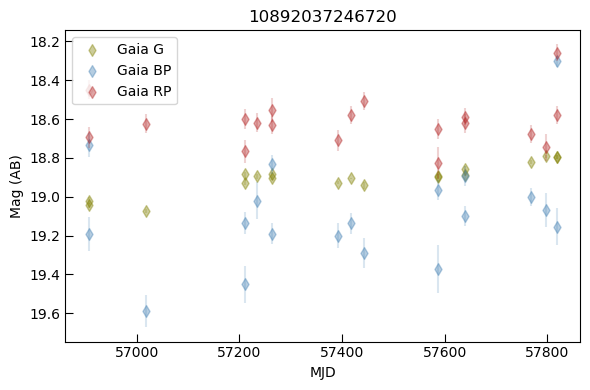

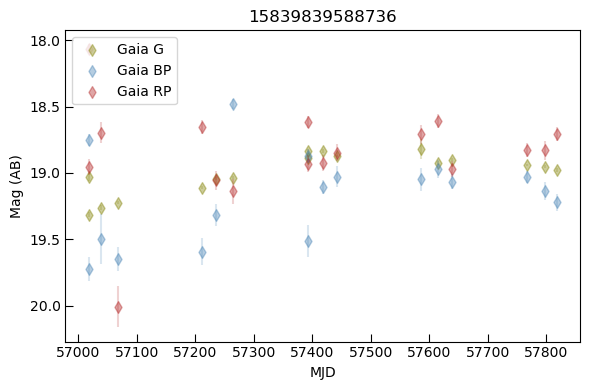

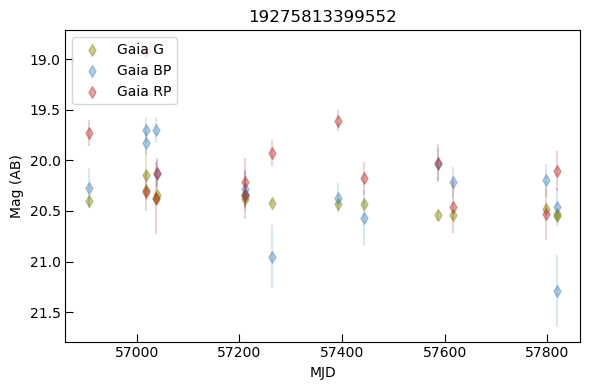

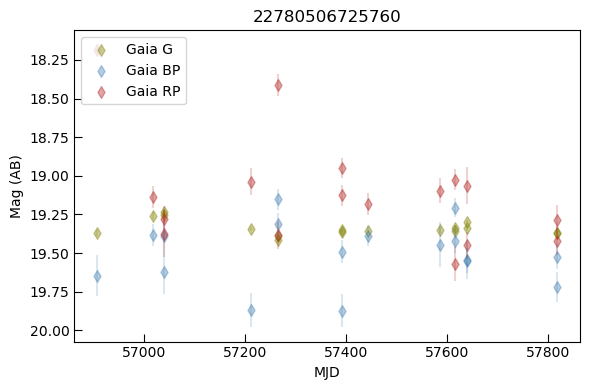

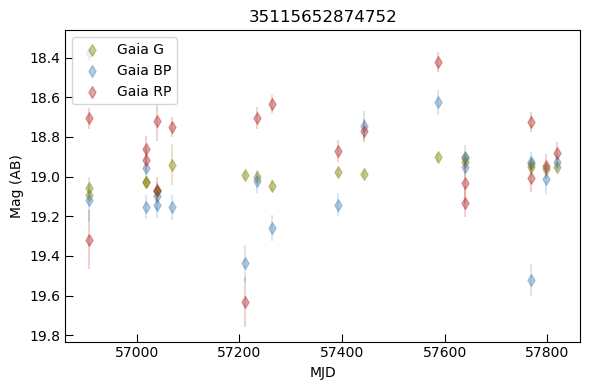

In [19]:
filter_colors = {
    "G": "olive",
    "BP": "steelblue",
    "RP": "firebrick",
}

#ndf_sorted = ndf.sort_values("Name")

for i in range(len(df_tmp)):#len(ndf_sorted)):
    row = df_tmp.iloc[i]
    gaia_lc = row["gaia_lc"]

    fig, ax = plt.subplots(figsize=(6,4))

    # --- Gaia DR3 ---
    if isinstance(gaia_lc, pd.DataFrame) and len(gaia_lc) > 0:
        gaia_bands = gaia_lc["band"]
        for band in ["G", "BP", "RP"]:
            band_idx = gaia_bands == band
            color = filter_colors[band]
            t = gaia_lc["mjd"][band_idx]
            mag = gaia_lc["mag"][band_idx]
            mag_err = gaia_lc["mag_err"][band_idx]
            ax.scatter(
                t, mag, marker="d", color=color, label=f"Gaia {band}", alpha=0.4
            )
            plt.errorbar(t, mag, mag_err, ls="", color=color, alpha=0.2)


    ax.invert_yaxis()
    ax.set_xlabel("MJD")
    ax.set_ylabel("Mag (AB)")
    ax.set_title(row['Source'])
    ax.legend(loc="upper left")
    ax.tick_params(axis='both', which='major', direction='in', size=6)  
    plt.tight_layout()

## run the whole operation